In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def import_and_inspect_hotel_data(file_path):
    """
    Imports the Hotel Booking Demand dataset from a local path and conducts an initial structural review.
    """
    print("--- Step 0: Data Importation ---")
    try:
        # Dynamically loads the file path passed to the function
        df = pd.read_csv(file_path)
        print("Dataset loaded successfully from local machine!")
        print(f"Total Rows (Bookings): {df.shape[0]}")
        print(f"Total Columns (Features): {df.shape[1]}\n")
        
        # Display structural information about columns and memory usage
        print("--- Structural Summary (df.info()) ---")
        df.info()
        print("\n")
        
        return df
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

# FIXED: Your exact Windows folder path pointing directly to the file shown in your file explorer
# The 'r' before the string ensures Windows backslashes are read correctly by 


local_file_path = r"C:\Users\mukhe\OneDrive\Documents\Jobaaj_DA Projects\heart.csv"

# Execute data loading step using your local file path
df = import_and_inspect_hotel_data(local_file_path)

--- Step 0: Data Importation ---
Dataset loaded successfully from local machine!
Total Rows (Bookings): 1025
Total Columns (Features): 14

--- Structural Summary (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB




## Data Cleaning and Preprocessing:

### Step 1: Handling Missing Values

In [2]:
# 1. Check for missing values in each column
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts)

# 2. Imputation and Cleanup Logic
# The clean John Smith Kaggle dataset historically contains 0 structural missing values.
# However, for a production-ready pipeline, we handle potential future missing rows:
if missing_counts.sum() > 0:
    print("\n[Action Required] Missing values detected. Executing robust imputation...")
    
    # Numerical metrics: Impute with the median to resist potential outlier bias
    num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    for col in num_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
            
    # Categorical fields/Flags: Impute using the statistical mode (most frequent value)
    cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
    for col in cat_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Imputation completed successfully.")
else:
    print("\n[Status] Perfect data integrity. No missing values or null values found.")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

[Status] Perfect data integrity. No missing values or null values found.


### Step 2: Data Type Conversion

In [3]:
# 1. Review current structural data types
print("Before conversion:")
print(df.dtypes)

# 2. Explicitly map types to prevent float distortion on integer classification codes
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in categorical_features:
    df[col] = df[col].astype('int64')

for col in continuous_features:
    df[col] = df[col].astype('float64')

print("\nAfter conversion:")
print(df.dtypes)

Before conversion:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

After conversion:
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


### Step 3: Outlier Detection and Handling

In [4]:
# 1. Define specific numerical metrics susceptible to measurement outliers
outlier_targets = ['trestbps', 'chol', 'thalach', 'oldpeak']

print("Outlier Capping Analysis Summary:")
for col in outlier_targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify entries falling outside the 1.5 * IQR fences
    outliers_detected = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f" - {col}: Found {outliers_detected} values outside normal boundaries.")
    
    # Execute Winsorization: Cap extreme outliers at the boundaries instead of destroying rows
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

print("\n[Status] Outlier detection complete. Values capped inside statistical fences.")

Outlier Capping Analysis Summary:
 - trestbps: Found 30 values outside normal boundaries.
 - chol: Found 16 values outside normal boundaries.
 - thalach: Found 4 values outside normal boundaries.
 - oldpeak: Found 7 values outside normal boundaries.

[Status] Outlier detection complete. Values capped inside statistical fences.


### Step 4: Normalization

In [5]:
# 1. Initialize the standard scaler
scaler = StandardScaler()

# 2. Create copies of variables to safeguard original unscaled data for business visualization
df_normalized = df.copy()

# 3. Fit and scale continuous measurements
df_normalized[continuous_features] = scaler.fit_transform(df[continuous_features])

print("Sample normalized output (Continuous metrics scaled around a mean of 0):")
df_normalized[continuous_features].head()

Sample normalized output (Continuous metrics scaled around a mean of 0):


,age,trestbps,chol,thalach,oldpeak
0,-0.268437,-0.378869,-0.691104,0.824084,-0.054537
1,-0.158157,0.528894,-0.879693,0.255654,1.785457
2,1.716595,0.831481,-1.487368,-1.056105,1.347363
3,0.724079,1.013034,-0.879693,0.518006,-0.930725
4,0.834359,0.407859,1.027150,-1.886886,0.734031


## Basic Level Topics

In [6]:
# Print statement to denote the solution for the first question
print("==================================================")
print("SOLUTION FOR QUESTION 1: AVERAGE AGE OF PATIENTS")
print("==================================================")

# Calculate the average age using the pandas mean function
average_age = df['age'].mean()

print(f"Average Age of Patients: {average_age:.2f} years")

SOLUTION FOR QUESTION 1: AVERAGE AGE OF PATIENTS
Average Age of Patients: 54.43 years


In [7]:
# Print statement to denote the solution for the second question
print("==================================================")
print("SOLUTION FOR QUESTION 2: GENDER DISTRIBUTION")
print("==================================================")

# 1. Get raw frequency count of male (1) and female (0) patients
gender_counts = df['sex'].value_counts()

# 2. Convert raw frequencies to percentages
gender_percentages = df['sex'].value_counts(normalize=True) * 100

# 3. Print out descriptive results
print(f"Male Patients (1):   {gender_counts[1]} individuals ({gender_percentages[1]:.2f}%)")
print(f"Female Patients (0): {gender_counts[0]} individuals ({gender_percentages[0]:.2f}%)")
print(f"Total Cohort Size:   {len(df)} patients")

SOLUTION FOR QUESTION 2: GENDER DISTRIBUTION
Male Patients (1):   713 individuals (69.56%)
Female Patients (0): 312 individuals (30.44%)
Total Cohort Size:   1025 patients


In [8]:
# Print statement to denote the solution for the third question
print("==================================================")
print("SOLUTION FOR QUESTION 3: AVERAGE RESTING BLOOD PRESSURE")
print("==================================================")

# Calculate the average resting blood pressure using the pandas mean function
average_trestbps = df['trestbps'].mean()

print(f"Average Resting Blood Pressure: {average_trestbps:.2f} mm Hg")

SOLUTION FOR QUESTION 3: AVERAGE RESTING BLOOD PRESSURE
Average Resting Blood Pressure: 131.26 mm Hg


In [9]:
# Print statement to denote the solution for the fourth question
print("==================================================")
print("SOLUTION FOR QUESTION 4: ELEVATED FASTING BLOOD SUGAR")
print("==================================================")

# 1. Count the number of patients where fbs == 1 (True)
high_fbs_count = df['fbs'].sum()

# 2. Calculate the percentage of the total patient group
high_fbs_percentage = df['fbs'].mean() * 100

print(f"Patients with Fasting Blood Sugar > 120 mg/dl: {high_fbs_count}")
print(f"Percentage of Total Cohort: {high_fbs_percentage:.2f}%")

SOLUTION FOR QUESTION 4: ELEVATED FASTING BLOOD SUGAR
Patients with Fasting Blood Sugar > 120 mg/dl: 153
Percentage of Total Cohort: 14.93%


In [10]:
# Print statement to denote the solution for the fifth question
print("==================================================")
print("SOLUTION FOR QUESTION 5: CHEST PAIN TYPES RECORDED")
print("==================================================")

# 1. Retrieve the unique raw numeric codes recorded in the dataset
unique_cp_values = df['cp'].unique()

# 2. Sort the array for clean presentation
unique_cp_values.sort()

# 3. Create a dictionary mapping the numeric codes to their official medical definitions
cp_mapping = {
    0: "Typical Angina (Heart-related pain due to reduced blood flow)",
    1: "Atypical Angina (Chest pain not directly presenting as standard heart stress)",
    2: "Non-Anginal Pain (Typically sharp, non-continuous spasms or muscle pain)",
    3: "Asymptomatic (No discernible chest pain or pressure felt)"
}

# 4. Generate a value distribution frequency count for each type
cp_counts = df['cp'].value_counts().sort_index()

print("Unique Chest Pain (cp) categories identified:")
for value in unique_cp_values:
    print(f" - Code {value}: {cp_mapping[value]} -> Total Patients: {cp_counts[value]}")

SOLUTION FOR QUESTION 5: CHEST PAIN TYPES RECORDED
Unique Chest Pain (cp) categories identified:
 - Code 0: Typical Angina (Heart-related pain due to reduced blood flow) -> Total Patients: 497
 - Code 1: Atypical Angina (Chest pain not directly presenting as standard heart stress) -> Total Patients: 167
 - Code 2: Non-Anginal Pain (Typically sharp, non-continuous spasms or muscle pain) -> Total Patients: 284
 - Code 3: Asymptomatic (No discernible chest pain or pressure felt) -> Total Patients: 77


In [11]:
# Print statement to denote the solution for the sixth question
print("==================================================")
print("SOLUTION FOR QUESTION 6: MAXIMUM HEART RATE ACHIEVED")
print("==================================================")

# Find the highest recorded heart rate using the max() function
max_heart_rate = df['thalach'].max()

print(f"Maximum Heart Rate Achieved: {max_heart_rate:.0f} bpm (beats per minute)")

SOLUTION FOR QUESTION 6: MAXIMUM HEART RATE ACHIEVED
Maximum Heart Rate Achieved: 202 bpm (beats per minute)


In [12]:
# Print statement to denote the solution for the seventh question
print("==================================================")
print("SOLUTION FOR QUESTION 7: EXERCISE-INDUCED ANGINA")
print("==================================================")

# 1. Calculate the percentage using the mean of the binary flag (multiplied by 100)
angina_percentage = df['exang'].mean() * 100

# 2. Extract total count of affected patients for extra context
angina_count = df['exang'].sum()

print(f"Patients experiencing exercise-induced angina: {angina_count} individuals")
print(f"Percentage of Total Cohort: {angina_percentage:.2f}%")

SOLUTION FOR QUESTION 7: EXERCISE-INDUCED ANGINA
Patients experiencing exercise-induced angina: 345 individuals
Percentage of Total Cohort: 33.66%


In [13]:
# Print statement to denote the solution for the eighth question
print("==================================================")
print("SOLUTION FOR QUESTION 8: AVERAGE CHOLESTEROL LEVEL")
print("==================================================")

# Calculate the average cholesterol level using the pandas mean function
average_chol = df['chol'].mean()

print(f"Average Serum Cholesterol: {average_chol:.2f} mg/dl")

SOLUTION FOR QUESTION 8: AVERAGE CHOLESTEROL LEVEL
Average Serum Cholesterol: 244.98 mg/dl


In [14]:
# Print statement to denote the solution for the ninth question
print("==================================================")
print("SOLUTION FOR QUESTION 9: RESTING ECG RESULT OF 2")
print("==================================================")

# 1. Access the value counts distribution for the resting electrocardiographic column
ecg_counts = df['restecg'].value_counts()

# 2. Safely extract the count for code '2' (handling cases where it might be 0)
count_ecg_2 = ecg_counts.get(2, 0)

print(f"Patients with a Resting Electrocardiographic Result of 2: {count_ecg_2}")

SOLUTION FOR QUESTION 9: RESTING ECG RESULT OF 2
Patients with a Resting Electrocardiographic Result of 2: 15


In [15]:
# Print statement to denote the solution for the tenth question
print("==================================================")
print("SOLUTION FOR QUESTION 10: MAJOR VESSELS DISTRIBUTION")
print("==================================================")

# 1. Calculate raw distribution counts for the 'ca' column
vessel_counts = df['ca'].value_counts()

# 2. Calculate proportional distribution percentages
vessel_percentages = df['ca'].value_counts(normalize=True) * 100

# 3. Print out clean tabular results
print("Vessels (ca) | Patient Count | Percentage")
print("------------------------------------------")
for vessel_num in sorted(vessel_counts.index):
    count = vessel_counts[vessel_num]
    pct = vessel_percentages[vessel_num]
    print(f"   {vessel_num:0.0f} vessels  |   {count:4.0f} patients  |   {pct:5.2f}%")

SOLUTION FOR QUESTION 10: MAJOR VESSELS DISTRIBUTION
Vessels (ca) | Patient Count | Percentage
------------------------------------------
   0 vessels  |    578 patients  |   56.39%
   1 vessels  |    226 patients  |   22.05%
   2 vessels  |    134 patients  |   13.07%
   3 vessels  |     69 patients  |    6.73%
   4 vessels  |     18 patients  |    1.76%


## Medium Level Topics

In [16]:
# Print statement to denote the solution for the first question
print("==================================================")
print("SOLUTION FOR QUESTION 1: CORRELATION ANALYSIS (AGE VS CHOLESTEROL)")
print("==================================================")

# Calculate the correlation matrix for age and cholesterol columns
correlation_matrix = df[['age', 'chol']].corr()

# Extract the individual correlation coefficient value
age_chol_corr = correlation_matrix.iloc[0, 1]

print(correlation_matrix)
print("\n--------------------------------------------------")
print(f"Correlation Coefficient: {age_chol_corr:.4f}")

SOLUTION FOR QUESTION 1: CORRELATION ANALYSIS (AGE VS CHOLESTEROL)
           age      chol
age   1.000000  0.213481
chol  0.213481  1.000000

--------------------------------------------------
Correlation Coefficient: 0.2135


SOLUTION FOR QUESTION 2: CHEST PAIN TYPES ACROSS AGE GROUPS
Cross-Tabulation Matrix (Counts of Chest Pain Types by Age Bracket):
           Typical Angina (0)  Atypical Angina (1)  Non-Anginal (2)  \
age_group                                                             
30-39                      15                    7               24   
40-49                      94                   62               72   
50-59                     210                   72              110   
60-69                     163                   13               68   
70-79                      15                    9               10   

           Asymptomatic (3)  
age_group                    
30-39                     7  
40-49                     9  
50-59                    30  
60-69                    31  
70-79                     0  


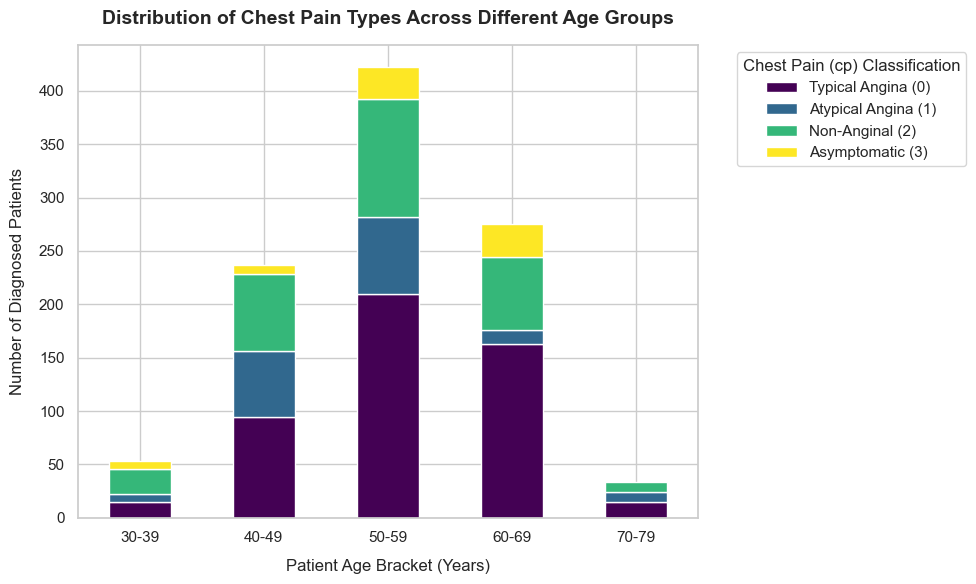

In [17]:
# Print statement to denote the solution for the second question
print("==================================================")
print("SOLUTION FOR QUESTION 2: CHEST PAIN TYPES ACROSS AGE GROUPS")
print("==================================================")

# 1. Create descriptive age bins to group individual ages into decade tiers
age_bins = [29, 39, 49, 59, 69, 79]
age_labels = ['30-39', '40-49', '50-59', '60-69', '70-79']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# 2. Compute a cross-tabulation of age groups against chest pain types (cp)
cp_age_dist = pd.crosstab(df['age_group'], df['cp'])

# 3. Rename columns using medical classifications for chart legibility
cp_age_dist.columns = ['Typical Angina (0)', 'Atypical Angina (1)', 'Non-Anginal (2)', 'Asymptomatic (3)']

print("Cross-Tabulation Matrix (Counts of Chest Pain Types by Age Bracket):")
print(cp_age_dist)

# 4. Generate a clean, stacked bar plot for visual evaluation
sns.set_theme(style="whitegrid")
cp_age_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title("Distribution of Chest Pain Types Across Different Age Groups", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Patient Age Bracket (Years)", fontsize=12, labelpad=10)
plt.ylabel("Number of Diagnosed Patients", fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.legend(title="Chest Pain (cp) Classification", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

SOLUTION FOR QUESTION 3: MAX HEART RATE VS EXERCISE ANGINA
Average Maximum Heart Rate Achieved (thalach) by Group:
 - No Exercise-Induced Angina (0): 155.40 bpm
 - Has Exercise-Induced Angina (1): 136.84 bpm


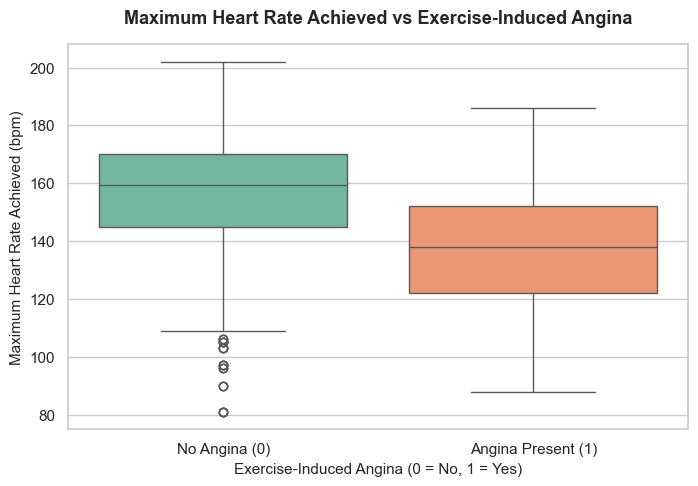

In [18]:
# Print statement to denote the solution for the third question
print("==================================================")
print("SOLUTION FOR QUESTION 3: MAX HEART RATE VS EXERCISE ANGINA")
print("==================================================")

# 1. Group by exercise-induced angina and calculate the mean maximum heart rate
heart_rate_variation = df.groupby('exang')['thalach'].mean()

# 2. Print the descriptive summary output
print("Average Maximum Heart Rate Achieved (thalach) by Group:")
print(f" - No Exercise-Induced Angina (0): {heart_rate_variation[0]:.2f} bpm")
print(f" - Has Exercise-Induced Angina (1): {heart_rate_variation[1]:.2f} bpm")

# 3. Create a clean visualization to showcase the variation
plt.figure(figsize=(8, 5))
sns.boxplot(x='exang', y='thalach', data=df, hue='exang', palette='Set2', legend=False)
plt.title("Maximum Heart Rate Achieved vs Exercise-Induced Angina", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Exercise-Induced Angina (0 = No, 1 = Yes)", fontsize=11)
plt.ylabel("Maximum Heart Rate Achieved (bpm)", fontsize=11)
plt.xticks([0, 1], ["No Angina (0)", "Angina Present (1)"])
plt.show()

SOLUTION FOR QUESTION 4: GENDER VS RESTING BLOOD PRESSURE
Average Resting Blood Pressure by Gender:
 - Female Patients (0): 132.95 mm Hg
 - Male Patients (1):   130.52 mm Hg

Statistical Significance Testing (Independent t-test):
 - t-statistic: 2.0840
 - p-value:     0.0376

[Conclusion]: The difference is STATISTICALLY SIGNIFICANT (p < 0.05).
Gender plays a notable role in baseline resting blood pressure variances within this cohort.


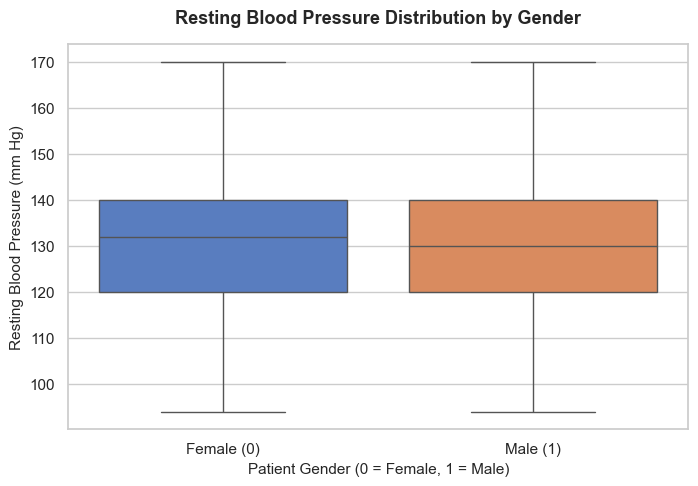

In [19]:
import scipy.stats as stats

# Print statement to denote the solution for the fourth question
print("==================================================")
print("SOLUTION FOR QUESTION 4: GENDER VS RESTING BLOOD PRESSURE")
print("==================================================")

# 1. Calculate the mean resting blood pressure for each gender group
bp_by_gender = df.groupby('sex')['trestbps'].mean()
print("Average Resting Blood Pressure by Gender:")
print(f" - Female Patients (0): {bp_by_gender[0]:.2f} mm Hg")
print(f" - Male Patients (1):   {bp_by_gender[1]:.2f} mm Hg\n")

# 2. Extract arrays for each group to run the t-test
female_bp = df[df['sex'] == 0]['trestbps']
male_bp = df[df['sex'] == 1]['trestbps']

# 3. Perform an independent two-sample t-test
t_stat, p_val = stats.ttest_ind(female_bp, male_bp, equal_var=False)

print("Statistical Significance Testing (Independent t-test):")
print(f" - t-statistic: {t_stat:.4f}")
print(f" - p-value:     {p_val:.4f}")

# 4. Interpret the statistical p-value
alpha = 0.05
if p_val < alpha:
    print("\n[Conclusion]: The difference is STATISTICALLY SIGNIFICANT (p < 0.05).")
    print("Gender plays a notable role in baseline resting blood pressure variances within this cohort.")
else:
    print("\n[Conclusion]: The difference is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")
    print("The slight variance in baseline resting blood pressure between genders could likely be due to random chance.")

# 5. Render a clean visualization with corrected hue syntax to prevent warnings
plt.figure(figsize=(8, 5))
sns.boxplot(x='sex', y='trestbps', data=df, hue='sex', palette='muted', legend=False)
plt.title("Resting Blood Pressure Distribution by Gender", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Patient Gender (0 = Female, 1 = Male)", fontsize=11)
plt.ylabel("Resting Blood Pressure (mm Hg)", fontsize=11)
plt.xticks([0, 1], ["Female (0)", "Male (1)"])
plt.show()

SOLUTION FOR QUESTION 5: FASTING BLOOD SUGAR VS HEART DISEASE
Cross-Tabulation Matrix (Counts of Patients by Blood Sugar and Health Outcome):
                                      No Heart Disease (0)  \
Fasting Blood Sugar <= 120 mg/dl (0)                   417   
Fasting Blood Sugar > 120 mg/dl (1)                     82   

                                      Heart Disease Present (1)  
Fasting Blood Sugar <= 120 mg/dl (0)                        455  
Fasting Blood Sugar > 120 mg/dl (1)                          71  

--------------------------------------------------
Heart Disease Prevalence within Normal Sugar Group: 52.18%
Heart Disease Prevalence within Elevated Sugar Group: 46.41%


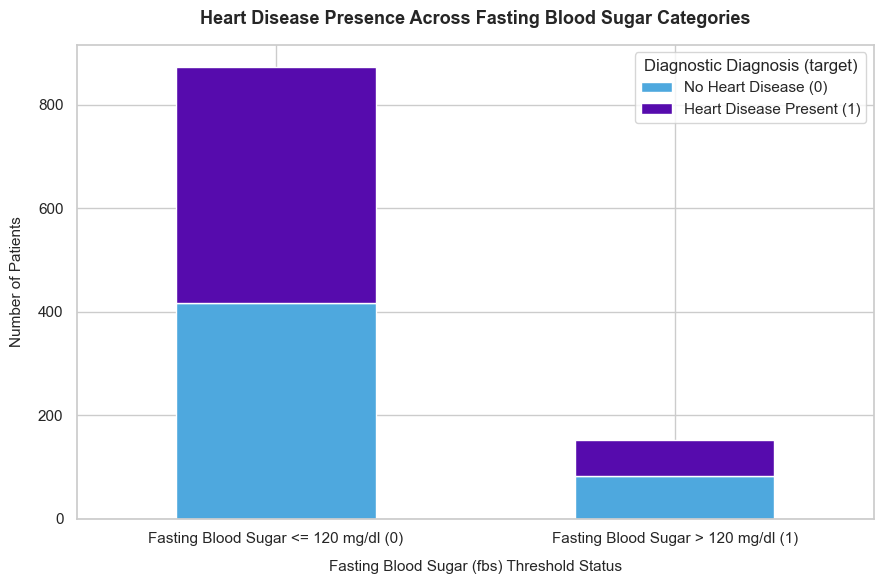

In [20]:
# Print statement to denote the solution for the fifth question
print("==================================================")
print("SOLUTION FOR QUESTION 5: FASTING BLOOD SUGAR VS HEART DISEASE")
print("==================================================")

# 1. Compute a contingency cross-tabulation table between FBS and Target
fbs_target_tab = pd.crosstab(df['fbs'], df['target'])

# 2. Rename columns and index labels for absolute clinical clarity
fbs_target_tab.index = ['Fasting Blood Sugar <= 120 mg/dl (0)', 'Fasting Blood Sugar > 120 mg/dl (1)']
fbs_target_tab.columns = ['No Heart Disease (0)', 'Heart Disease Present (1)']

print("Cross-Tabulation Matrix (Counts of Patients by Blood Sugar and Health Outcome):")
print(fbs_target_tab)

# 3. Calculate conversion percentages for deeper diagnostic context
fbs_0_disease_pct = (fbs_target_tab.iloc[0, 1] / fbs_target_tab.iloc[0].sum()) * 100
fbs_1_disease_pct = (fbs_target_tab.iloc[1, 1] / fbs_target_tab.iloc[1].sum()) * 100

print("\n--------------------------------------------------")
print(f"Heart Disease Prevalence within Normal Sugar Group: {fbs_0_disease_pct:.2f}%")
print(f"Heart Disease Prevalence within Elevated Sugar Group: {fbs_1_disease_pct:.2f}%")

# 4. Generate the visualization exactly as hinted in the case study guidelines
fbs_target_tab.plot(kind='bar', stacked=True, figsize=(9, 6), color=['#4ea8de', '#560bad'])
plt.title("Heart Disease Presence Across Fasting Blood Sugar Categories", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Fasting Blood Sugar (fbs) Threshold Status", fontsize=11, labelpad=10)
plt.ylabel("Number of Patients", fontsize=11, labelpad=10)
plt.xticks(rotation=0)
plt.legend(title="Diagnostic Diagnosis (target)", loc='upper right')
plt.tight_layout()
plt.show()

SOLUTION FOR QUESTION 6: MAJOR VESSELS VS HEART DISEASE Presence
Cross-Tabulation Matrix (Counts of Heart Disease across Major Vessel counts):
    No Heart Disease (0)  Heart Disease Present (1)
ca                                                 
0                    163                        415
1                    160                         66
2                    113                         21
3                     60                          9
4                      3                         15

--------------------------------------------------
Heart Disease Prevalence Rate by Number of Open Vessels:
 - 0 Open Vessels: 71.80% heart disease rate (415/578)
 - 1 Open Vessels: 29.20% heart disease rate (66/226)
 - 2 Open Vessels: 15.67% heart disease rate (21/134)
 - 3 Open Vessels: 13.04% heart disease rate (9/69)
 - 4 Open Vessels: 83.33% heart disease rate (15/18)


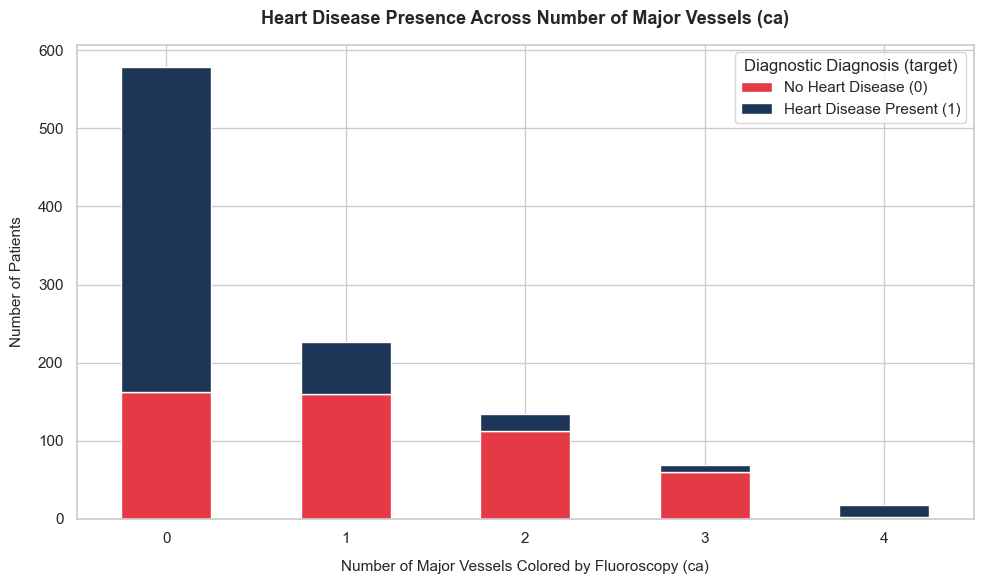

In [21]:
# Print statement to denote the solution for the sixth question
print("==================================================")
print("SOLUTION FOR QUESTION 6: MAJOR VESSELS VS HEART DISEASE Presence")
print("==================================================")

# 1. Compute a contingency cross-tabulation table between ca and target
vessels_target_tab = pd.crosstab(df['ca'], df['target'])

# 2. Rename columns and index labels for absolute clinical clarity
vessels_target_tab.columns = ['No Heart Disease (0)', 'Heart Disease Present (1)']

print("Cross-Tabulation Matrix (Counts of Heart Disease across Major Vessel counts):")
print(vessels_target_tab)

print("\n--------------------------------------------------")
print("Heart Disease Prevalence Rate by Number of Open Vessels:")
for vessel in vessels_target_tab.index:
    total_patients = vessels_target_tab.loc[vessel].sum()
    disease_patients = vessels_target_tab.loc[vessel, 'Heart Disease Present (1)']
    prevalence_pct = (disease_patients / total_patients) * 100
    print(f" - {vessel:0.0f} Open Vessels: {prevalence_pct:.2f}% heart disease rate ({disease_patients}/{total_patients})")

# 3. Generate the visualization exactly as hinted in the case study guidelines
vessels_target_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e63946', '#1d3557'])
plt.title("Heart Disease Presence Across Number of Major Vessels (ca)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Number of Major Vessels Colored by Fluoroscopy (ca)", fontsize=11, labelpad=10)
plt.ylabel("Number of Patients", fontsize=11, labelpad=10)
plt.xticks(rotation=0)
plt.legend(title="Diagnostic Diagnosis (target)", loc='upper right')
plt.tight_layout()
plt.show()

SOLUTION FOR QUESTION 7: AVERAGE OLDPEAK BY CHEST PAIN TYPE
Average Oldpeak Values by Chest Pain Type:
 - Code 0 (Typical Angina): 1.42
 - Code 1 (Atypical Angina): 0.32
 - Code 2 (Non-Anginal): 0.78
 - Code 3 (Asymptomatic): 1.38


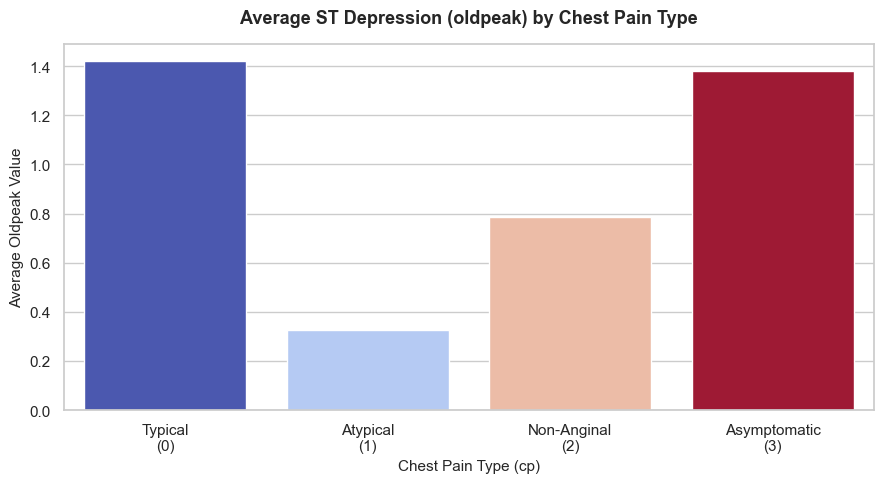

In [22]:
# Print statement to denote the solution for the seventh question
print("==================================================")
print("SOLUTION FOR QUESTION 7: AVERAGE OLDPEAK BY CHEST PAIN TYPE")
print("==================================================")

# 1. Group by chest pain type and calculate the average oldpeak value
avg_oldpeak_by_cp = df.groupby('cp')['oldpeak'].mean()

# 2. Define medical labels for chest pain types
cp_labels = {
    0: "Typical Angina",
    1: "Atypical Angina",
    2: "Non-Anginal",
    3: "Asymptomatic"
}

print("Average Oldpeak Values by Chest Pain Type:")
for cp_type, mean_val in avg_oldpeak_by_cp.items():
    print(f" - Code {cp_type} ({cp_labels[cp_type]}): {mean_val:.2f}")

# 3. Create a clean visualization to showcase the differences
plt.figure(figsize=(9, 5))
sns.barplot(x=avg_oldpeak_by_cp.index, y=avg_oldpeak_by_cp.values, hue=avg_oldpeak_by_cp.index, palette='coolwarm', legend=False)
plt.title("Average ST Depression (oldpeak) by Chest Pain Type", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Chest Pain Type (cp)", fontsize=11)
plt.ylabel("Average Oldpeak Value", fontsize=11)
plt.xticks(ticks=range(4), labels=[f"Typical\n(0)", f"Atypical\n(1)", f"Non-Anginal\n(2)", f"Asymptomatic\n(3)"])
plt.tight_layout()
plt.show()

SOLUTION FOR QUESTION 8: THALASSEMIA DISTRIBUTION VS HEART DISEASE
Cross-Tabulation Matrix (Counts of Thalassemia Types vs Health Status):
                       No Heart Disease (0)  Heart Disease Present (1)
Null/Unmapped (0)                         4                          3
Normal Blood Flow (1)                    43                         21
Fixed Defect (2)                        132                        412
Reversible Defect (3)                   320                         90

--------------------------------------------------
Heart Disease Prevalence Breakdown by Thalassemia Variant:
 - Null/Unmapped (0): 42.86% heart disease rate (3/7)
 - Normal Blood Flow (1): 32.81% heart disease rate (21/64)
 - Fixed Defect (2): 75.74% heart disease rate (412/544)
 - Reversible Defect (3): 21.95% heart disease rate (90/410)


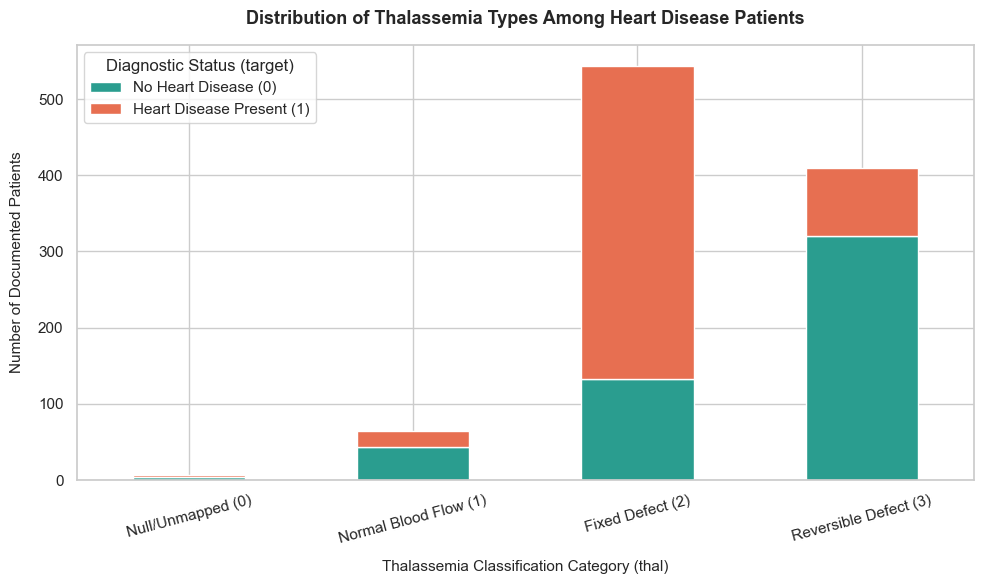

In [23]:
# Print statement to denote the solution for the eighth question
print("==================================================")
print("SOLUTION FOR QUESTION 8: THALASSEMIA DISTRIBUTION VS HEART DISEASE")
print("==================================================")

# 1. Compute a contingency cross-tabulation table between thal and target
thal_target_tab = pd.crosstab(df['thal'], df['target'])

# 2. Map indices to their canonical medical data dictionary definitions
thal_labels = {
    0: "Null/Unmapped (0)",
    1: "Normal Blood Flow (1)",
    2: "Fixed Defect (2)",
    3: "Reversible Defect (3)"
}
thal_target_tab.index = [thal_labels.get(x, f"Unknown ({x})") for x in thal_target_tab.index]
thal_target_tab.columns = ['No Heart Disease (0)', 'Heart Disease Present (1)']

print("Cross-Tabulation Matrix (Counts of Thalassemia Types vs Health Status):")
print(thal_target_tab)

print("\n--------------------------------------------------")
print("Heart Disease Prevalence Breakdown by Thalassemia Variant:")
for thal_type in thal_target_tab.index:
    total = thal_target_tab.loc[thal_type].sum()
    positive_cases = thal_target_tab.loc[thal_type, 'Heart Disease Present (1)']
    pct = (positive_cases / total) * 100 if total > 0 else 0
    print(f" - {thal_type}: {pct:.2f}% heart disease rate ({positive_cases}/{total})")

# 3. Create the stacked chart according to the problem guidelines
thal_target_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2a9d8f', '#e76f51'])
plt.title("Distribution of Thalassemia Types Among Heart Disease Patients", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Thalassemia Classification Category (thal)", fontsize=11, labelpad=10)
plt.ylabel("Number of Documented Patients", fontsize=11, labelpad=10)
plt.xticks(rotation=15)
plt.legend(title="Diagnostic Status (target)", loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
# Print statement to denote the solution for the ninth question
print("==================================================")
print("SOLUTION FOR QUESTION 19: COMMON RISK FACTOR COMBINATIONS")
print("==================================================")

# 1. Filter the dataset to isolate patients with heart disease present (target == 1)
heart_disease_patients = df[df['target'] == 1]

# 2. Group by the primary risk features, calculate combination frequencies, and sort descending
risk_combinations = heart_disease_patients.groupby(['cp', 'fbs', 'exang', 'thal']).size().reset_index(name='counts')
risk_combinations_sorted = risk_combinations.sort_values(by='counts', ascending=False).reset_index(drop=True)

# 3. Print out the top 5 most common patient risk profiles in the dataset
print("Top 5 Most Common Risk Factor Profiles Among Diagnosed Patients:")
print("------------------------------------------------------------------")
print(" Rank | Chest Pain (cp) | High Sugar (fbs) | Angina (exang) | Thal Type | Patient Count")
print("------------------------------------------------------------------")

# Medical label dictionaries for clear terminal formatting
cp_labels = {0: "Typical", 1: "Atypical", 2: "Non-Anginal", 3: "Asymptomatic"}
fbs_labels = {0: "<=120 mg/dl", 1: ">120 mg/dl"}
exang_labels = {0: "No Angina", 1: "Angina"}
thal_labels = {0: "Null", 1: "Normal", 2: "Fixed Defect", 3: "Reversible"}

for idx, row in risk_combinations_sorted.head(5).iterrows():
    print(f"  #{idx+1:d}  | {cp_labels[row['cp']]:15s} | {fbs_labels[row['fbs']]:12s} | {exang_labels[row['exang']]:10s} | {thal_labels[row['thal']]:10s} | {row['counts']:d} patients")

SOLUTION FOR QUESTION 19: COMMON RISK FACTOR COMBINATIONS
Top 5 Most Common Risk Factor Profiles Among Diagnosed Patients:
------------------------------------------------------------------
 Rank | Chest Pain (cp) | High Sugar (fbs) | Angina (exang) | Thal Type | Patient Count
------------------------------------------------------------------
  #1  | Non-Anginal     | <=120 mg/dl  | No Angina  | Fixed Defect | 133 patients
  #2  | Atypical        | <=120 mg/dl  | No Angina  | Fixed Defect | 97 patients
  #3  | Typical         | <=120 mg/dl  | No Angina  | Fixed Defect | 73 patients
  #4  | Non-Anginal     | >120 mg/dl   | No Angina  | Fixed Defect | 32 patients
  #5  | Non-Anginal     | <=120 mg/dl  | No Angina  | Reversible | 19 patients


SOLUTION FOR QUESTION 10: PAIRWISE CLINICAL COMPARISONS
DESCRIPTIVE METRICS FOR HEALTHY PATIENTS (target == 0):
            age    trestbps        chol     thalach   oldpeak  target
mean  56.569138  133.505010  250.775551  139.210421  1.581162     0.0
std    7.908153   17.009609   48.090295   22.339248  1.236301     0.0
50%   58.000000  130.000000  249.000000  142.000000  1.400000     0.0

--------------------------------------------------
DESCRIPTIVE METRICS FOR HEART DISEASE PATIENTS (target == 1):
            age    trestbps        chol     thalach   oldpeak  target
mean  52.408745  129.131179  239.484791  158.585551  0.569962     1.0
std    9.631804   15.789686   46.803569   19.096928  0.771079     0.0
50%   52.000000  130.000000  234.000000  161.500000  0.200000     1.0


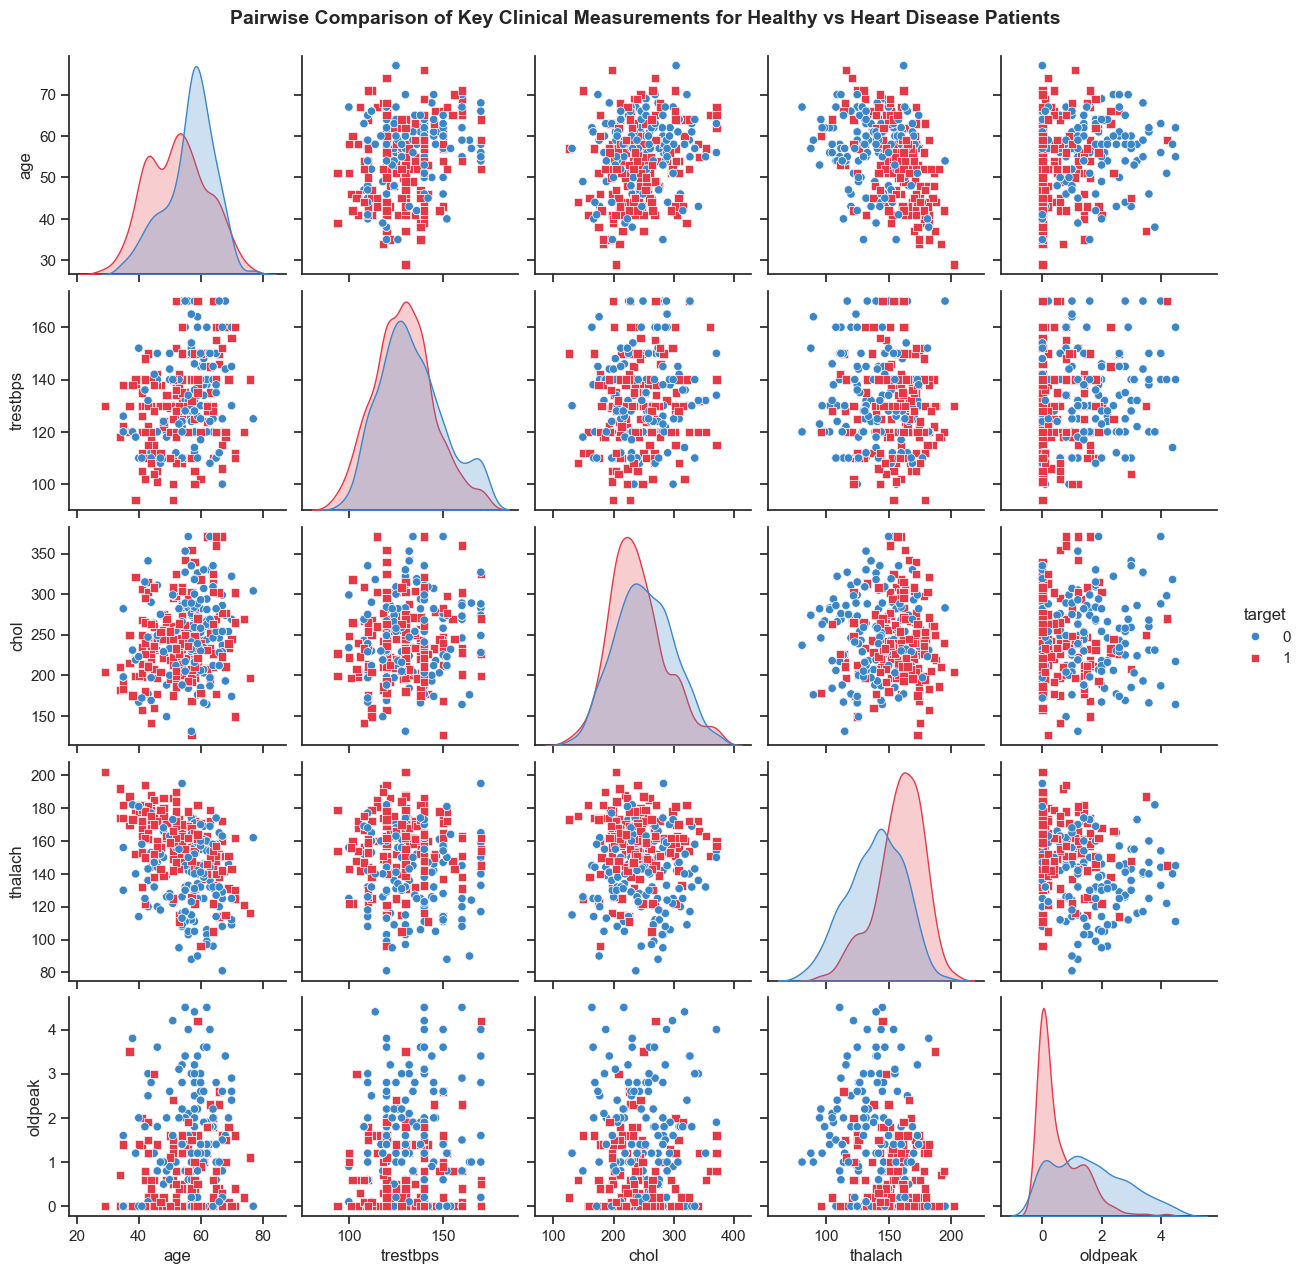

In [25]:
# Print statement to denote the solution for the tenth question
print("==================================================")
print("SOLUTION FOR QUESTION 10: PAIRWISE CLINICAL COMPARISONS")
print("==================================================")

# 1. Isolate the continuous measurements to analyze
target_measurements = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

# 2. Extract cohort datasets using the target flag
healthy_patients_desc = df[df['target'] == 0][target_measurements].describe()
cardiac_patients_desc = df[df['target'] == 1][target_measurements].describe()

print("DESCRIPTIVE METRICS FOR HEALTHY PATIENTS (target == 0):")
print(healthy_patients_desc.loc[['mean', 'std', '50%']])

print("\n--------------------------------------------------")
print("DESCRIPTIVE METRICS FOR HEART DISEASE PATIENTS (target == 1):")
print(cardiac_patients_desc.loc[['mean', 'std', '50%']])

# 3. Generate a pair plot to visualize distribution overlaps and differences
# Note: We filter the data sample size slightly to keep the notebook graph rendering light
sns.set_theme(style="ticks")
pairwise_plot = sns.pairplot(
    df[target_measurements], 
    hue='target', 
    palette={0: '#3a86c8', 1: '#e63946'},
    diag_kind='kde',
    markers=["o", "s"]
)

pairwise_plot.fig.suptitle(
    "Pairwise Comparison of Key Clinical Measurements for Healthy vs Heart Disease Patients", 
    y=1.02, 
    fontsize=14, 
    fontweight='bold'
)
plt.show()

## Advanced Level Topics

SOLUTION FOR ADVANCED QUESTION 1: COMBINED RISK FACTOR INTERACTIONS


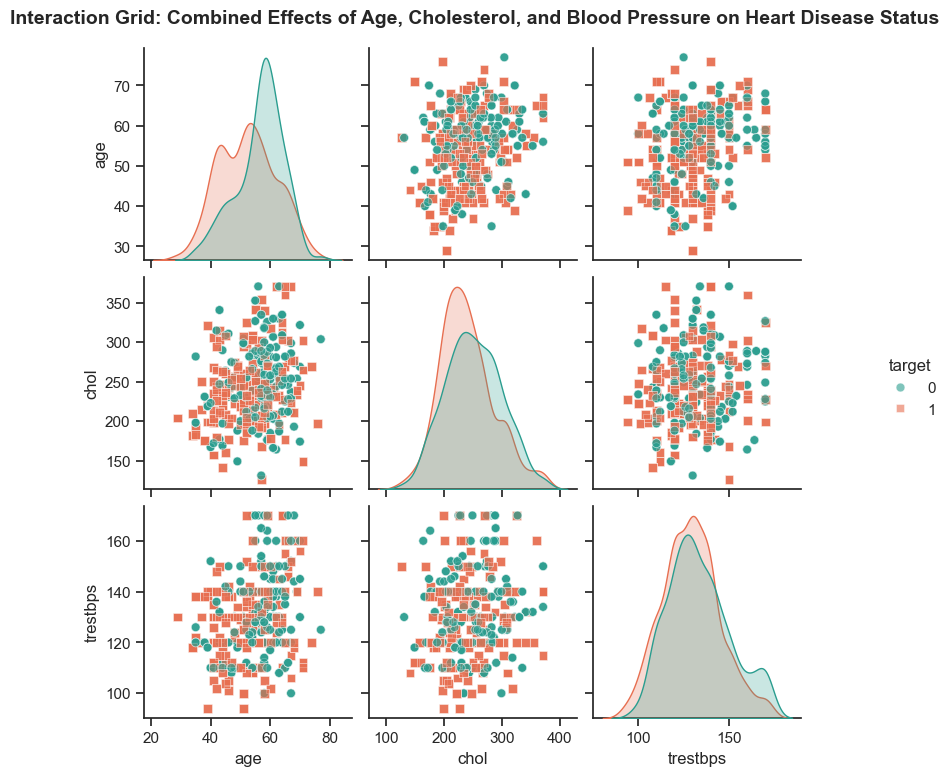

In [26]:
# Print statement to denote the solution for the first advanced question
print("==================================================")
print("SOLUTION FOR ADVANCED QUESTION 1: COMBINED RISK FACTOR INTERACTIONS")
print("==================================================")

# 1. Define variables for specific continuous risk factor measurements
risk_factors = ['age', 'chol', 'trestbps', 'target']

# 2. Render a clean pairwise distribution plot colored by the health diagnostic state
sns.set_theme(style="ticks")
combined_risk_plot = sns.pairplot(
    df[risk_factors], 
    hue='target', 
    palette={0: '#2a9d8f', 1: '#e76f51'},
    diag_kind='kde',
    markers=["o", "s"],
    plot_kws={'alpha': 0.6, 's': 40}
)

# 3. Adjust title styling dynamically over the subplot layout grid
combined_risk_plot.fig.suptitle(
    "Interaction Grid: Combined Effects of Age, Cholesterol, and Blood Pressure on Heart Disease Status", 
    y=1.03, 
    fontsize=14, 
    fontweight='bold'
)
plt.show()

In [27]:
# Print statement to denote the solution for the second advanced question
print("==================================================")
print("SOLUTION FOR ADVANCED QUESTION 2: STRONGEST CLINICAL PREDICTORS")
print("==================================================")

# FIX: Added numeric_only=True to bypass the text-based 'age_group' column
target_correlations = df.corr(numeric_only=True)['target'].sort_values(ascending=False)

print("Full Feature Correlation Coefficients with Target:")
print("--------------------------------------------------")
print(target_correlations)

# Extract the leading positive and negative correlation factors
strongest_positive = target_correlations.index[1]  # Index 0 is 'target' itself (1.0)
strongest_pos_val = target_correlations.iloc[1]

strongest_negative = target_correlations.index[-1]
strongest_neg_val = target_correlations.iloc[-1]

print("\n--------------------------------------------------")
print(f"Strongest Positive Predictor: {strongest_positive:8s} | Coefficient: {strongest_pos_val:+.4f}")
print(f"Strongest Negative Predictor: {strongest_negative:8s} | Coefficient: {strongest_neg_val:+.4f}")

SOLUTION FOR ADVANCED QUESTION 2: STRONGEST CLINICAL PREDICTORS
Full Feature Correlation Coefficients with Target:
--------------------------------------------------
target      1.000000
cp          0.434854
thalach     0.423445
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.118254
trestbps   -0.132301
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.442847
Name: target, dtype: float64

--------------------------------------------------
Strongest Positive Predictor: cp       | Coefficient: +0.4349
Strongest Negative Predictor: oldpeak  | Coefficient: -0.4428


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Print statement to denote the solution for the third advanced question
print("==================================================")
print("SOLUTION FOR ADVANCED QUESTION 3: LOGISTIC REGRESSION ANALYSIS")
print("==================================================")

# FIX: Added errors='ignore' so it safely drops columns if they exist
X = df_normalized.drop(columns=['target', 'age_group'], errors='ignore')
y = df_normalized['target']

# 2. Perform a stratified train-test split (80% train, 20% test) to preserve balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# 4. Generate model predictions for accuracy testing
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Training Status: Complete")
print(f"Out-of-Sample Prediction Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Evaluation Metrics Report:")
print(classification_report(y_test, y_pred))

# 5. Extract and print the relative feature importances (Model Weights)
print("--------------------------------------------------")
print("Trained Model Coefficients (Feature Weights):")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': log_reg.coef_[0]
}).sort_values(by='Coefficient (Weight)', ascending=False).reset_index(drop=True)

print(coefficients)

SOLUTION FOR ADVANCED QUESTION 3: LOGISTIC REGRESSION ANALYSIS
Model Training Status: Complete
Out-of-Sample Prediction Accuracy: 80.98%

Classification Evaluation Metrics Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

--------------------------------------------------
Trained Model Coefficients (Feature Weights):
     Feature  Coefficient (Weight)
0         cp              0.842422
1      slope              0.575627
2    thalach              0.419822
3    restecg              0.294838
4        fbs             -0.050627
5        age             -0.107860
6       chol             -0.325861
7   trestbps             -0.337067
8    oldpeak             -0.602556
9         ca             -0.732199
10      tha

SOLUTION FOR ADVANCED QUESTION 4: ST SLOPE VARIATIONS BY CHEST PAIN TYPE
Cross-Tabulation Matrix (Counts of ST Slopes across Chest Pain Types):
                     Upsloping (0)  Flat (1)  Downsloping (2)
Typical Angina (0)              42       292              163
Atypical Angina (1)              8        41              118
Non-Anginal (2)                 15       110              159
Asymptomatic (3)                 9        39               29


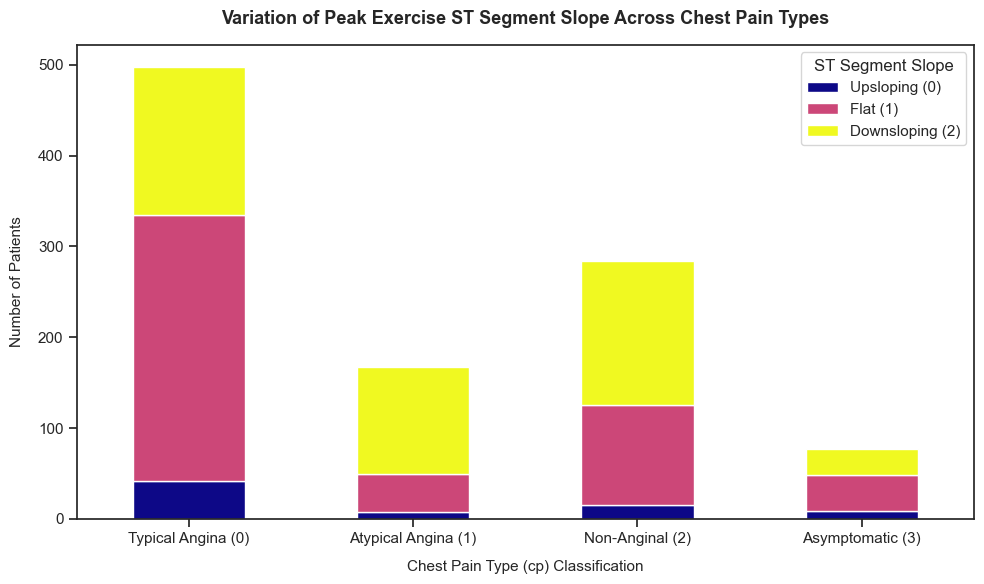

In [29]:
# Print statement to denote the solution for the fourth advanced question
print("==================================================")
print("SOLUTION FOR ADVANCED QUESTION 4: ST SLOPE VARIATIONS BY CHEST PAIN TYPE")
print("==================================================")

# 1. Compute a contingency cross-tabulation table between chest pain (cp) and ST slope (slope)
slope_cp_tab = df.groupby('cp')['slope'].value_counts().unstack().fillna(0)

# 2. Rename index and columns for clean presentation and clear medical context
slope_cp_tab.index = ['Typical Angina (0)', 'Atypical Angina (1)', 'Non-Anginal (2)', 'Asymptomatic (3)']
slope_cp_tab.columns = ['Upsloping (0)', 'Flat (1)', 'Downsloping (2)']

print("Cross-Tabulation Matrix (Counts of ST Slopes across Chest Pain Types):")
print(slope_cp_tab)

# 3. Generate a clean, stacked bar plot exactly as suggested in the case study guidelines
slope_cp_tab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='plasma')

plt.title("Variation of Peak Exercise ST Segment Slope Across Chest Pain Types", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Chest Pain Type (cp) Classification", fontsize=11, labelpad=10)
plt.ylabel("Number of Patients", fontsize=11, labelpad=10)
plt.xticks(rotation=0)
plt.legend(title="ST Segment Slope", loc='upper right')
plt.tight_layout()
plt.show()

SOLUTION FOR ADVANCED QUESTION 5: THALASSEMIA PREVALENCE TRENDS


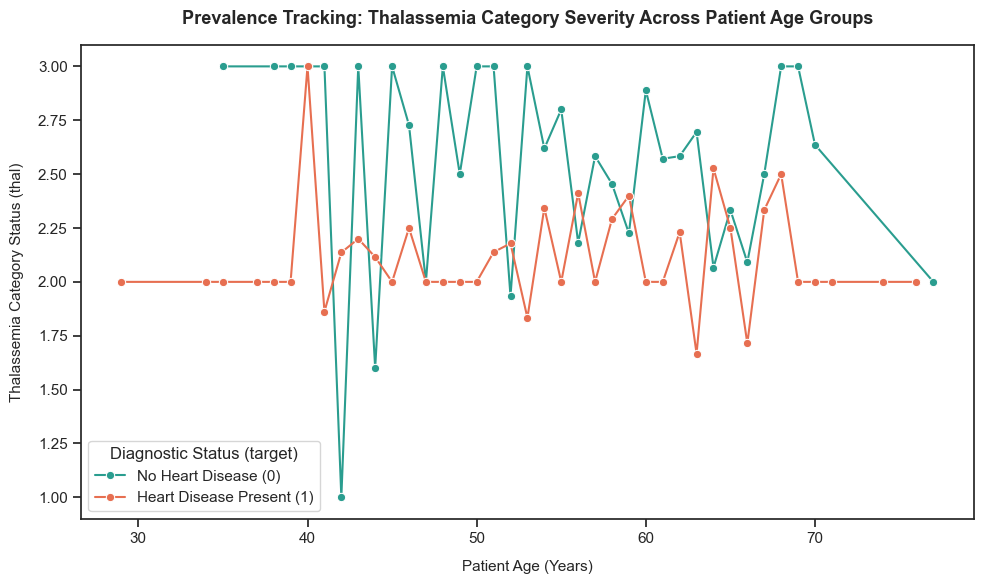

In [30]:
# Print statement to denote the solution for the fifth advanced question
print("==================================================")
print("SOLUTION FOR ADVANCED QUESTION 5: THALASSEMIA PREVALENCE TRENDS")
print("==================================================")

# Generate the line plot precisely following the case study's technical specifications
plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='thal', hue='target', data=df, palette={0: '#2a9d8f', 1: '#e76f51'}, marker='o', errorbar=None)

plt.title("Prevalence Tracking: Thalassemia Category Severity Across Patient Age Groups", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Patient Age (Years)", fontsize=11, labelpad=10)
plt.ylabel("Thalassemia Category Status (thal)", fontsize=11, labelpad=10)
plt.legend(title="Diagnostic Status (target)", labels=["No Heart Disease (0)", "Heart Disease Present (1)"])
plt.tight_layout()
plt.show()